
#  Sprint 9 - Creación de funciones, estructuras de datos y bucles

> **Contexto:** Un cliente necesita una lista de programas sencillos que le faciliten procesos cotidianos.  
> Para cada ejercicio debes entregar:  
> 1. La **definición de la función** (`def ...`)  
> 2. Su **ejecución con output visible** para demostrar que funciona  
> 
> ⚠️ Todo el código debe ser lo más **reproducible** posible. No uses `print()` para guardar resultados.



---

## ⭐ Nivel 1

---



### 1. Calculadora del Índice de Masa Corporal (IMC)

Escribe una función que **calcule el IMC** a partir de los datos introducidos por el usuario/a.

**Requisitos:**
- El usuario debe ingresar su **peso** y **altura**
- La función debe **clasificar el resultado** en sus categorías correspondientes (bajo peso, normal, sobrepeso, obesidad...)

> **Consejo:** Valida los datos de entrada antes de calcular. Si los valores no tienen un formato adecuado o no son razonables, la función debe mostrar un **mensaje de advertencia**.

🔗 Referencia: [Índice de masa corporal — ¿qué es y cómo se calcula?](https://muysalud.com/salud/indice-de-masa-corporal-imc-que-es-y-como-se-calcula/) 

In [7]:
# Calculadora de IMC


def calculo_IMC(peso, altura):
    """
    Calcula el IMC a partir del peso (kg) y altura (m), y devuelve el IMC + la categoría asociada.
    """
    # Validación de valores razonables
    if peso <= 0 or peso > 400:
        raise ValueError("El peso debe ser mayor que 0 y menor que 400 kg.")
    if altura <= 0 or altura > 2.5:
        raise ValueError("La altura debe ser mayor que 0 y menor que 2.5 metros.")

    imc = round(peso / pow(altura, 2), 2)  # Formula de IMC = peso/altura al cuadrado

    # Clasificación según IMC
    if imc < 18.5:
        categoria = "bajo peso"
    elif imc < 25:
        categoria = "peso adecuado"
    elif imc < 30:
        categoria = "sobrepeso"
    else:
        categoria = "obesidad"

    return imc, categoria

In [8]:
# Bloque de interacción con el usuario
# (esto se ejecuta para demostrar el funcionamiento)

dato_peso = False
while not dato_peso:
    try:
        peso_usuario = float(
            input("Por favor, introducí tu peso en kg (hasta 2 decimales): ")
        )
        dato_peso = True
    except ValueError:  # Manejo de error q permite q el programa se siga ejecutando
        print("Dato erróneo. Usá solo números y el punto como separador de decimales.")

dato_altura = False
while not dato_altura:
    try:
        altura_usuario = float(
            input("Por favor, introducí tu altura en metros (hasta 2 decimales): ")
        )
        dato_altura = True
    except ValueError:
        print("Dato erróneo. Usá solo números y el punto como separador de decimales.")

In [9]:
# Llamamos a la función y mostramos el resultado

try:
    imc, categoria = calculo_IMC(peso_usuario, altura_usuario)
    print(f"\nTu índice de masa corporal (IMC) es de {imc}.")
    print(f"Según tu IMC, tu peso se encuentra en la categoría de {categoria}.")
except ValueError as e:
    print(f"\nNo se pudo calcular el IMC: {e}")


Tu índice de masa corporal (IMC) es de 25.83.
Según tu IMC, tu peso se encuentra en la categoría de sobrepeso.


In [10]:
# DEMO


def calcular_imc(peso, altura):
    return peso / (altura**2)


def clasificar_imc(imc):
    if imc < 18.5:
        return "Bajo peso"
    elif imc < 25:
        return "Peso normal"
    elif imc < 30:
        return "Sobrepeso"
    else:
        return "Obesidad"


def orquestador():
    try:
        peso = 80
        altura = 1.76
        imc = calcular_imc(peso, altura)
        categoria = clasificar_imc(imc)
        print(f"Tu IMC es {imc:.2f} y tu categoría es {categoria}.")
    except ValueError:
        print("Por favor ingresa valores numéricos válidos.")


orquestador()

Tu IMC es 25.83 y tu categoría es Sobrepeso.


--- 
### 2. Conversor de Temperaturas

Existen diversas unidades de temperatura: **Celsius (°C)**, **Fahrenheit (°F)**, **Kelvin (K)**, Rankine (°Ra) y Réaumur (°Re).

**Requisitos:**
- Selecciona **al menos 2 conversores**
- Al introducir una temperatura, debe devolver **como mínimo 2 conversiones**
- El resultado debe poder **guardarse** (recuerda: un `print()` no se puede guardar)

> **Consejo:** Valida los datos de entrada. Si el formato no es correcto, muestra un mensaje de advertencia.

> **(EXTRA):** Piensa cómo almacenar **todas las conversiones posibles en un solo objeto** (¿Lista? ¿Diccionario? ¿DataFrame?) en lugar de escribir muchos `if/else` según la unidad de origen y destino.

---



In [33]:
# Conversor de Temperaturas - Completo y validado


def convertir_temperatura(valor, unidad_origen):
    """
    Convierte una temperatura a todas las unidades.
    Unidades: 'C'elsius, 'K'elvin, 'F'ahrenheit, 'R'ankine, 'Re'aumur
    Retorna diccionario con todas las conversiones.
    """
    # Validación de valor razonable (ej: -273 a 1000°C aprox)
    if valor < -300 or valor > 2000:
        raise ValueError(
            "Temperatura fuera de rango razonable (-300 a 2000°C)."
        )  # Manejo de error q permite q el programa se siga ejecutando

    # Diccionario de fórmulas base para las conversiones
    conversiones = {
        "C": {
            "K": lambda t: t + 273.15,
            "F": lambda t: 9 * t / 5 + 32,
            "R": lambda t: 9 * t / 5 + 491.67,
            "Re": lambda t: 4 * t / 5,
        },
        "K": {
            "C": lambda t: t - 273.15,
            "F": lambda t: 9 * (t - 273.15) / 5 + 32,
            "R": lambda t: 9 * (t - 273.15) / 5 + 491.67,
            "Re": lambda t: 4 * (t - 273.15) / 5,
        },
        "F": {
            "C": lambda t: 5 * (t - 32) / 9,
            "K": lambda t: 5 * (t - 32) / 9 + 273.15,
            "R": lambda t: t + 459.67,
            "Re": lambda t: 4 * (t - 32) / 9,
        },
        "R": {
            "C": lambda t: 5 * (t - 491.67) / 9,
            "K": lambda t: 5 * (t - 491.67) / 9 + 273.15,
            "F": lambda t: t - 459.67,
            "Re": lambda t: 4 * (t - 491.67) / 9,
        },
        "Re": {
            "C": lambda t: 5 * t / 4,
            "K": lambda t: 5 * t / 4 + 273.15,
            "F": lambda t: 9 * t / 4 + 32,
            "R": lambda t: 9 * t / 4 + 491.67,
        },
    }

    if unidad_origen not in conversiones:
        raise ValueError("Unidad origen inválida. Usa: C, K, F, R, Re")

    resultado = {"origen": f"{round(valor, 2)} {unidad_origen}"}
    unidades_destino = ["C", "K", "F", "R", "Re"]

    for ud in unidades_destino:
        if ud != unidad_origen:
            conv = round(conversiones[unidad_origen][ud](valor), 2)
            resultado[ud] = conv

    return resultado

In [35]:
print(
    "\n===         EJECUTANDO CON INPUT              === \n "
    "Introduce la temperatura en la ventana superior:"
)

# Bloque input con validación (tu código mejorado)
try:
    temp = float(input("Temperatura: "))
    unidad = input("Unidad (C/K/F/R/Re): ").upper().strip()
    res = convertir_temperatura(temp, unidad)
    print(f"\n{res['origen']} → {res}")
except ValueError as e:
    print(f"Error: {e}")


===         EJECUTANDO CON INPUT              === 
 Introduce la temperatura en la ventana superior:

20.0 C → {'origen': '20.0 C', 'K': 293.15, 'F': 68.0, 'R': 527.67, 'Re': 16.0}


---
### 3. Contador de Palabras de un Texto

Escribe una función que, **dado un texto**, muestre cuántas veces aparece cada palabra.

**Requisitos:**
- Gestiona todas las **casuísticas** que puedan hacer fallar el programa (mayúsculas, signos de puntuación, espacios extra, etc.)

> **(EXTRA):** Calcula la **longitud media de las palabras** del texto.  
> Ejemplo: `"¿Hola cómo va?"` → `(4 + 3 + 2) / 3 = 3.0`

---



In [13]:
import string


def limpiar_texto(texto):
    """
    Devuelve una lista de palabras limpias:
                                            - minúsculas
                                            - sin signos de puntuación
                                            - sin espacios vacíos
    """
    texto = texto.lower()

    for signo in string.punctuation + "¡¿":
        texto = texto.replace(signo, " ")

    palabras = texto.split()

    return palabras

In [14]:
def analizar_texto(texto):
    """
    La func devuelve:
            - diccionario de frecuencias
            - longitud media de las palabras
    """
    palabras = limpiar_texto(texto)

    # Conteo
    conteo = {}
    for palabra in palabras:
        conteo[palabra] = conteo.get(palabra, 0) + 1

    # Longitud media
    if not palabras:
        media = 0.0
    else:
        longitudes = [len(p) for p in palabras]
        media = round(sum(longitudes) / len(longitudes), 2)

    return conteo, media

In [15]:
texto = input("Ingrese texto para analizar")
frecuencias, media = analizar_texto(texto)
print("Frecuencias:", frecuencias)
print("Longitud media:", media)

Frecuencias: {'hola': 1, 'como': 1, 'te': 1, 'va': 1}
Longitud media: 3.0



--- 
### 4. Diccionario Inverso (con posibilidad de duplicados)

El cliente tiene una encuesta almacenada en un diccionario y necesita los resultados **al revés**: intercambiando claves y valores.

**Requisitos:**
- Si los valores originales son **únicos** → invertir el diccionario normalmente
- Si hay **valores duplicados** → la función debe:
  - Imprimir un **mensaje de advertencia**
  - Mostrar una **lista con los valores asociados a la clave repetida**

> Fíjate en los ejemplos de output esperado proporcionados en el enunciado original.

---


In [ ]:
def diccionario_inverso(diccionario):
    """
    Esta función crea un nuevo diccionario donde las claves de entrada se convierten en los valores y viceversa.

    Args:
        diccionario (dict): El diccionario de entrada.

    Returns:
        dict: El diccionario inverso.
    """

    inverso = {}

    for clave, valor in diccionario.items():

        if valor not in inverso:
            inverso[valor] = clave
        else:
            if not isinstance(inverso[valor], list):
                inverso[valor] = [inverso[valor]]

            inverso[valor].append(clave)

    return inverso

In [17]:
encuesta = {"A": "SI", "B": "NO", "C": "SI", "D": "SI"}
resultado = diccionario_inverso(encuesta)
print("Diccionario invertido:", resultado)

Diccionario invertido: {'SI': ['A', 'C', 'D'], 'NO': 'B'}


---

## ⭐ Nivel 2

---

### 1. Contador y ordenador de palabras de un texto.

El cliente quedó contento con el contador de palabras, pero ahora quiere leer archivos TXT y que calcule la frecuencia de cada palabra ordenadas dentro de las entradas habituales <br>
del diccionario según la letra con la que comienzan, es decir, las claves deben ir de la A a la Z y dentro de la A debemos ir de la A a Z.

In [ ]:
from collections import defaultdict
import string
from pprint import (
    pprint,
)  # mas comodo para leer q un print en estructuras anidadas dentro de diccionarios,


def diccionario_contador(texto):
    """
    Crea un diccionario que cuenta las palabras de un texto y clasifica las 
    palabras por su primer carácter.

    Args:
        texto (str): El texto a procesar.

    Returns:
        dict: Un diccionario con las letras como claves y sub-diccionarios con las 
        palabras que comienzan con cada letra.
    """

    palabras = texto.lower().split()

    conteo = defaultdict(int)

    for p in palabras:
        limpia = p.strip(
            string.punctuation
        )  # El argumento elimina los espacios en cada extremo de kada palabra
        if limpia:
            conteo[limpia] += 1

    resultado = {}

    for palabra, freq in conteo.items():
        letra = palabra[0]  # devuelve el primer carácter de la palabra

        if letra not in resultado:
            resultado[letra] = {}  # crea un dicc vacío bajo la letra

        resultado[letra][palabra] = freq  # añade la palabra dentro de ese dicc

    # ordenar palabras dentro de cada letra
    for letra in resultado:
        resultado[letra] = dict(sorted(resultado[letra].items()))

    return dict(sorted(resultado.items()))  # Ordenar las letras del resultado final

In [19]:
with open(
    "/Users/fedeur/IT Academy/Py/Sprint 9/tu me quieres blanca.txt", encoding="utf-8"
) as f:
    texto = f.read()

pprint(diccionario_contador(texto))

{'a': {'a': 3,
       'agua': 1,
       'al': 2,
       'alba': 4,
       'alcobas': 1,
       'alimenta': 1,
       'alma': 1,
       'amarga': 1,
       'azucena': 1},
 'b': {'baco': 1,
       'banquete': 1,
       'bebe': 1,
       'blanca': 3,
       'boca': 1,
       'bosques': 1,
       'buen': 1},
 'c': {'cabañas': 1,
       'carnes': 2,
       'casta': 3,
       'cerrada': 1,
       'con': 4,
       'conservas': 1,
       'copas': 1,
       'corola': 1,
       'corriste': 1,
       'cuando': 2,
       'cubierto': 1,
       'cuerpo': 1,
       'cuáles': 1},
 'd': {'de': 8, 'dejaste': 1, 'del': 1, 'diga': 1, 'dios': 2, 'duerme': 1},
 'e': {'el': 4,
       'ellas': 1,
       'en': 4,
       'engaño': 1,
       'enredada': 1,
       'entonces': 1,
       'escarcha': 1,
       'espumas': 1,
       'esqueleto': 1,
       'estrago': 1},
 'f': {'festejando': 1, 'filtrado': 1, 'frutos': 1},
 'h': {'habla': 1,
       'hacia': 1,
       'haya': 1,
       'hayas': 1,
       'hermana': 1,
 

---
### 2. Conversión de tipos de datos.

El cliente recibe una lista de datos y necesita generar dos listas, la primera donde estarán todos los elementos que pudieron convertirse en flotantes y la otra donde están los elementos que no pudieron convertirse. 

---

In [ ]:
def separar_convertibles(lista_datos):
    """
    Separa los elementos de una lista que pueden ser convertidos a float de aquellos que no lo pueden.

    Args:
        lista_datos (list): Lista que contiene elementos que pueden ser convertidos a float o no.

    Returns:
        Una tupla con dos listas. La primera lista contiene los elementos que se pudieron convertir a float, y la segunda lista contiene los elementos que no se pudieron convertir.
    """

    convertibles = []
    no_convertibles = []

    for item in lista_datos:

        # si es lista o tupla, recorrerla
        if isinstance(item, (list, tuple)):  # si es lista o tupla
            for subitem in item:
                try:
                    convertibles.append(float(subitem))  # intenta convertir a float
                except:
                    no_convertibles.append(subitem)

        # si es elemento simple
        else:
            try:
                convertibles.append(float(item))
            except:
                no_convertibles.append(item)

    return convertibles, no_convertibles

In [21]:
lista_ejemplo = [
    "1.3",
    "one",
    "1e10",
    "seven",
    "3-1/2",
    ("2", 1, 1.4, "not-a-number"),
    [1, 2, "3", "3.4"],
]

flotantes, no_flotantes = separar_convertibles(lista_ejemplo)

print("Convertibles:", flotantes)
print("No convertibles:", no_flotantes)

Convertibles: [1.3, 10000000000.0, 2.0, 1.0, 1.4, 1.0, 2.0, 3.0, 3.4]
No convertibles: ['one', 'seven', '3-1/2', 'not-a-number']


In [22]:
entrada = input("Introduce valores separados por coma: ")

lista = entrada.split(",")

flotantes, no_flotantes = separar_convertibles(lista)

print("Convertibles:", flotantes)
print("No convertibles:", no_flotantes)

Convertibles: [2.0, 2.0, 8.0]
No convertibles: [' cero']


---

## ⭐ ⭐ Nivel 2

---

### 1. Generador de Contraseñas

Explora el funcionamiento del módulo random de la librería numpy. 🔗 Random module in NumPy

En este punto, el cliente ha detectado un problema con las contraseñas que utilizan sus trabajadores. Asdf1234, fechas de cumpleaños o similares. Para solucionarlo, nos ha encargado una función de Python que genere contraseñas más seguras. La función debe depender de los siguientes parámetros:

longitud (int): Longitud de la contraseña
mayúsculas (bool = True): Si tiene que aparecer mayúsculas
minúsculas (bool = True): Si tiene que aparecer minúsculas
números (bool = True): Si tiene que aparecer números
signos (bool = False): Si tiene que aparecer caracteres especiales (,-$? o similares)
Así pues, si ejecutamos la función de la siguiente forma:

crear_contraseña(10, True, True, True, True)

Deberíamos obtener un output (que debemos poder guardar) del estilo:

9Er,5Vn8P$

Asegúrate de que se cumplan todos los criterios, y que estas contraseñas sean realmente aleatorias.

(EXTRA) Explora cómo podríamos hacer que la función copiara la contraseña automáticamente en el portapapeles del ordenador (como si la hubiéramos seleccionado y hecho ctrl+copy).

In [ ]:
import numpy as np
import string

def crear_contraseña(longitud, mayusculas=True, minusculas=True, numeros=True, signos=False):
    """
    Genera una contraseña aleatoria de longitud 'longitud' con los siguientes criterios:
    
    - Mayúsculas: si se especifica que sean incluidas (por defecto, sí)
    - Minúsculas: si se especifica que sean incluidas (por defecto, sí)
    - Números: si se especifica que sean incluidos (por defecto, sí)
    - Signos especiales: si se especifica que sean incluidos (por defecto, no)
    
    Args:
        longitud (int): La longitud de la contraseña a generar
        mayusculas (bool, optional): Si es True, se incluyen mayúsculas en la contraseña. Defaults to True.
        minusculas (bool, optional): Si es True, se incluyen minúsculas en la contraseña. Defaults to True.
        numeros (bool, optional): Si es True, se incluyen números en la contraseña. Defaults to True.
        signos (bool, optional): Si es True, se incluyen signos especiales en la contraseña. Defaults to False.

    Returns:
        str: La contraseña generada según los criterios especificados
    """

    chars = ""
    password = []

    if mayusculas:
        chars += string.ascii_uppercase
        password.append(np.random.choice(list(string.ascii_uppercase)))

    if minusculas:
        chars += string.ascii_lowercase
        password.append(np.random.choice(list(string.ascii_lowercase)))

    if numeros:
        chars += string.digits
        password.append(np.random.choice(list(string.digits)))

    if signos:
        chars += string.punctuation
        password.append(np.random.choice(list(string.punctuation)))

    if chars == "":
        return "Error: seleccioná al menos un tipo de carácter"

    # completar hasta la longitud deseada
    restantes = longitud - len(password)
    password += list(np.random.choice(list(chars), restantes))

    # mezclar
    np.random.shuffle(password)

    return "".join(password)

In [24]:
# Genero la contraseña y a guardo en una variable (además de mostrarla con Print)
pwd = crear_contraseña(6, True, True, True, True)
print("Contraseña generada:", pwd)

Contraseña generada: 2h[ZM4


In [ ]:
import pyperclip  # Me permite copiar en el portapapeles  (el contenido de una variable)

pyperclip.copy(pwd)
print("Contraseña copiada al portapapeles")

Contraseña copiada al portapapeles


---

# ⭐⭐⭐ Nivel 3

---

### 2. Procesamiento de datos simple

Una compañera de trabajo nos ha pedido un favor, aprovechando que sabe que estamos aprendiendo a programar. Tiene un histórico de partidos de fútbol catalán en un fichero, donde se almacenan los nombres de los equipos y los resultados. Necesita que procesemos los datos de forma automática, para extraer los resultados que necesita.

Utiliza el archivo "historic_partits.txt"

Necesita un programa que devuelva:

El número total de goles que ha marcado cada equipo. <br>
El nombre del equipo más goleador.<br>
El nombre del equipo más goleado <br>
La clasificación global (cada victoria: 3 pts, empate 1 pts, derrota 0 pts)<br>
Como referencia, los equipos con más puntos serían los siguientes:<br>

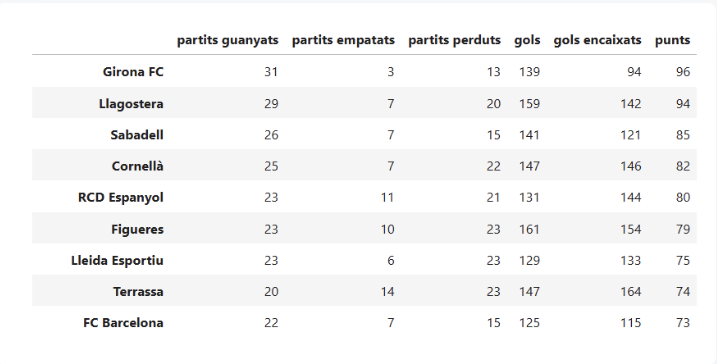

In [ ]:
from collections import defaultdict


def procesar_partidos(ruta="historic partits.txt"):
    """
    Procesa los datos de partidos y devuelve información sobre goles marcados, 
    goles recibidos y puntos obtenidos por cada equipo.

    Args:
        ruta (str): Ruta al archivo con la información de los partidos. Defaults to "historic partits.txt".

    Returns:
        Terna con diccionarios de goles marcados, goles recibidos y puntos obtenidos por cada equipo.
    """

    goles_marcados = defaultdict(int)
    goles_recibidos = defaultdict(int)
    puntos = defaultdict(int)

    with open(ruta, "r", encoding="utf-8") as f:
        for linea in f:
            linea = linea.strip()

            if not linea:
                continue

            # dividir por tabulación
            partes = linea.split("\t")

            if len(partes) != 3:
                continue

            equipo1, marcador, equipo2 = partes

            # limpiar posibles caracteres raros
            equipo1 = equipo1.strip()
            equipo2 = equipo2.strip()

            goles1, goles2 = map(int, marcador.split("-"))

            # goles
            goles_marcados[equipo1] += goles1
            goles_recibidos[equipo1] += goles2

            goles_marcados[equipo2] += goles2
            goles_recibidos[equipo2] += goles1

            # puntos
            if goles1 > goles2:
                puntos[equipo1] += 3
            elif goles1 < goles2:
                puntos[equipo2] += 3
            else:
                puntos[equipo1] += 1
                puntos[equipo2] += 1

    return goles_marcados, goles_recibidos, puntos

In [ ]:
def mostrar_clasificacion():
    
    goles_marc, goles_rec, pts = procesar_partidos()

    tabla = []

    for equipo in pts:
        gf = goles_marc[equipo]
        gc = goles_rec[equipo]
        tabla.append((equipo, pts[equipo], gf, gc))

    tabla.sort(key=lambda x: x[1], reverse=True)

    print("\n====== 🏆 CLASIFICACIÓN ======\n")
    print(f"{'Equipo':<20} {'GF':>4} {'GC':>4} {'PTS':>4}")
    print("-" * 36)

    for equipo, puntos, gf, gc in tabla:
        print(f"{equipo:<20} {gf:>4} {gc:>4} {puntos:>4}")

    max_goleador = max(goles_marc.items(), key=lambda x: x[1])
    max_goleado = max(goles_rec.items(), key=lambda x: x[1])

    print(f"\n⚽ Más goleador: {max_goleador[0]} ({max_goleador[1]} goles)")
    print(f"🥅 Más goleado: {max_goleado[0]} ({max_goleado[1]} goles)")

In [ ]:
mostrar_clasificacion()


====== 🏆 CLASIFICACIÓN ======

Equipo                 GF   GC  PTS
------------------------------------
Girona FC             139   94   96
Llagostera            159  142   94
Sabadell              141  121   85
Cornellà              147  146   82
RCD Espanyol          131  144   80
Figueres              161  154   79
Lleida Esportiu       129  133   75
Terrassa              147  164   74
FC Barcelona          125  115   73
Vilafranca            157  172   72
Badalona              134  124   68
Reus Deportiu         119  111   68
Nàstic de Tarragona   130  148   68
Granollers            122  117   67
Olot                  128  139   64
Sant Andreu           123  134   62
Manlleu               106  118   57
Prat                  106  111   56
Cerdanyola            117  133   56
Europa                 93   93   41

⚽ Más goleador: Figueres (161 goles)
🥅 Más goleado: Vilafranca (172 goles)
